In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv('data/kc_house_data_original.csv')

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


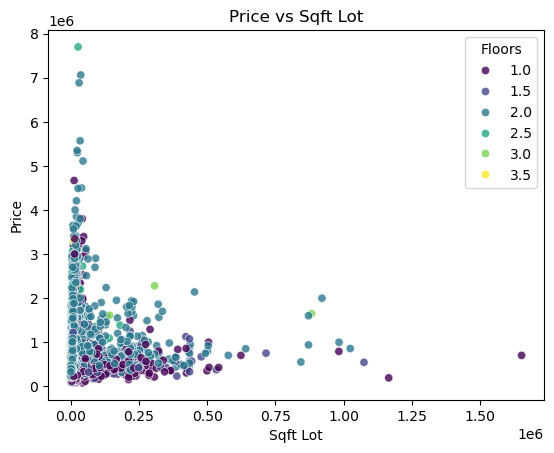

In [ ]:
#Create a scatter plot including price that also maps a third variable to either the color or size of the data markers
sns.scatterplot(
    data=df,
    x='sqft_lot',
    y='price',
    hue='floors',  
    palette='viridis',
    alpha=0.8
)

plt.title("Price vs Sqft Lot")
plt.xlabel("Sqft Lot")
plt.ylabel("Price")
plt.legend(title="Floors")
plt.show()

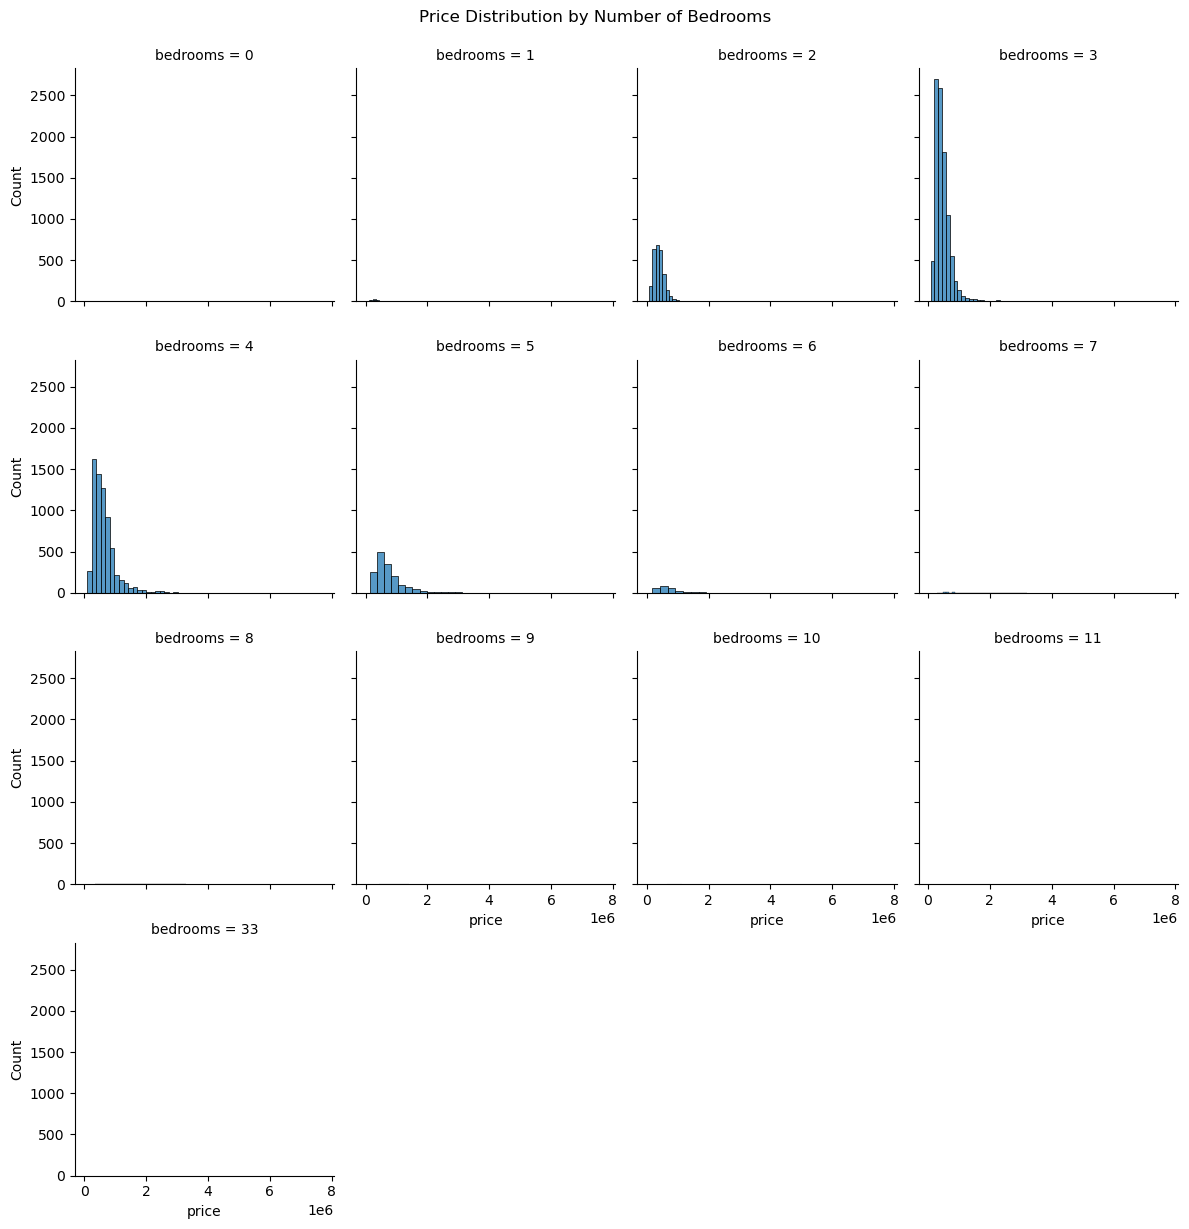

In [ ]:
#facet plot

g = sns.FacetGrid(df, col="bedrooms", col_wrap=4, height=3)
g.map(sns.histplot, "price", bins=30)
g.figure.suptitle("Price Distribution by Number of Bedrooms", y=1.02)
plt.show()

   year_month  count
0  2014-05-01   1768
1  2014-06-01   2180
2  2014-07-01   2211
3  2014-08-01   1940
4  2014-09-01   1774
5  2014-10-01   1878
6  2014-11-01   1411
7  2014-12-01   1471
8  2015-01-01    978
9  2015-02-01   1250
10 2015-03-01   1875
11 2015-04-01   2231
12 2015-05-01    646


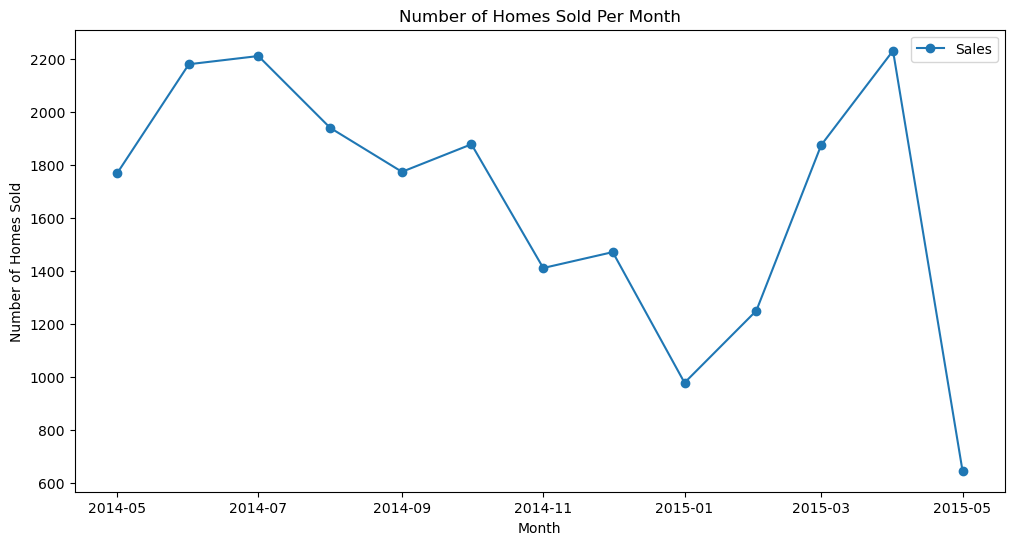

In [44]:
#Time Series Plot (Homes Sold by Month)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract year-month
df['year_month'] = df['date'].dt.to_period('M')

# Group by month
sales_pm = df.groupby('year_month').size().reset_index(name='count')

# Convert to timestamp
sales_pm['year_month'] = sales_pm['year_month'].dt.to_timestamp()

print(sales_pm)

# Create complete monthly range
full_range = pd.date_range(
    start=sales_pm['year_month'].min(),
    end=sales_pm['year_month'].max(),
    freq='MS'   # Month Start frequency
)

plt.figure(figsize=(12,6))
plt.plot(sales_pm['year_month'], sales_pm['count'], marker='o', label='Sales')
plt.title("Number of Homes Sold Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Homes Sold")
plt.legend()
plt.show()

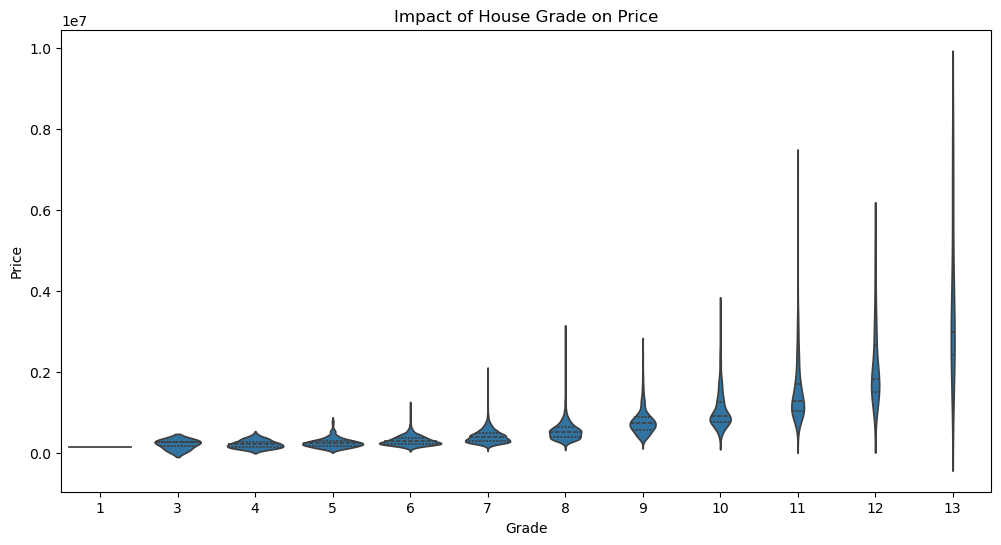

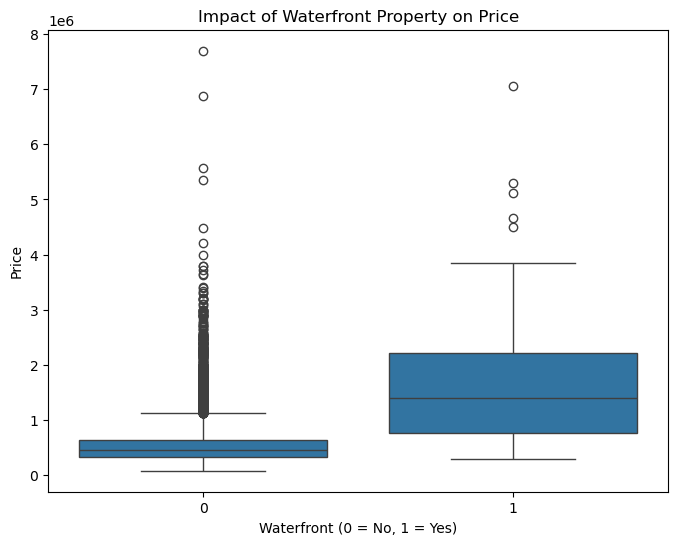

In [ ]:
#how price is impacted by Waterfront

plt.figure(figsize=(8,6))

sns.boxplot(data=df, x='waterfront', y='price')

plt.title("Impact of Waterfront Property on Price")
plt.xlabel("Waterfront (0 = No, 1 = Yes)")
plt.ylabel("Price")
plt.show()